(768, 9)


(614, 7)

(614,)

(154, 7)

(154,)

Confusion Matrix :  [[ 30   9]
 [  5 110]]
Accuracy Score :  0.9090909090909091
Accuracy in Percentage :  90 %


<Axes: xlabel='Predicted', ylabel='Actual'>

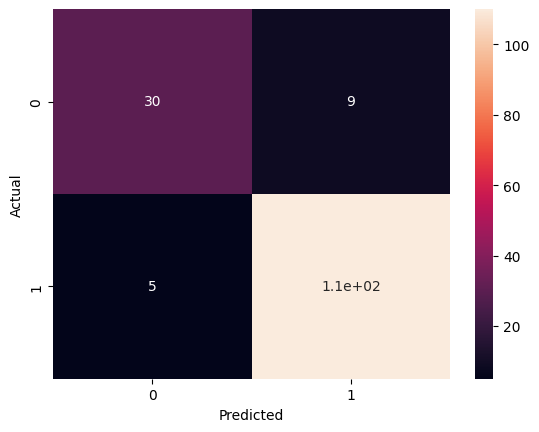

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn

# Reading Dataset
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv(r'diabetes_custom.csv')

print(data.shape)
data.head()

# Checking for null values
data.isnull().sum()

# Assigning dependent and independent variables
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']

X = data[feature_cols]
y = data.label

# Splitting dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=5
)

display(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Fitting the Model
model = LogisticRegression(solver='lbfgs', max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation Metrics
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print('Confusion Matrix : ', conf_mat)

Accuracy_score = metrics.accuracy_score(y_test, y_pred)

print('Accuracy Score : ', Accuracy_score)

print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')

# Confusion Matrix Heatmap
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Read dataset
data = pd.read_stata('/content/binary.dta')

# Explore dataset
print(data.head())
print(data.shape)
print(data.isnull().sum())
print(data.describe())

# Independent variables
X = data[['gre', 'gpa', 'rank']]

# Dependent variable
y = data['admit']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Display predictions
print("Predicted:")
print(y_pred)

print("Actual:")
print(y_test.values)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Model coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Predict admission for a new student
new_student = pd.DataFrame({
    'gre': [700],
    'gpa': [3.8],
    'rank': [2]
})

prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

print("Predicted Admission:", prediction[0])
print("Admission Probability:", probability[0])

   admit    gre   gpa  rank
0    0.0  380.0  3.61   3.0
1    1.0  660.0  3.67   3.0
2    1.0  800.0  4.00   1.0
3    1.0  640.0  3.19   4.0
4    0.0  520.0  2.93   4.0
(400, 4)
admit    0
gre      0
gpa      0
rank     0
dtype: int64
            admit         gre         gpa        rank
count  400.000000  400.000000  400.000000  400.000000
mean     0.317500  587.700012    3.389900    2.485000
std      0.466087  115.516663    0.380567    0.944462
min      0.000000  220.000000    2.260000    1.000000
25%      0.000000  520.000000    3.130000    2.000000
50%      0.000000  580.000000    3.395000    2.000000
75%      1.000000  660.000000    3.670000    3.000000
max      1.000000  800.000000    4.000000    4.000000
Predicted:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0.]
Actual:
[0. 0. 1. 0. 0. 